## Notebook 08 — PICRUSt2 Functional Profiling and Extended Diversity Analysis
### OgunBiome Pipeline — Phase 2 Expansion

**Purpose:** Analyse PICRUSt2 MetaCyc pathway abundance predictions across the
27-participant wint17 cohort. Add expanded diversity metrics (Chao1, Faith's PD,
Weighted UniFrac), rarefaction curves, Spearman correlation, LEfSe biomarker
discovery, longitudinal butyrate trajectory, and Random Forest responder prediction.

**PICRUSt2 runtime:** 2 hours 52 minutes on DigitalOcean Ubuntu 24.04,
4 vCPU / 8GB RAM + 16GB swap. EPA-ng phylogenetic placement of 882 ASVs
onto 26,868-organism reference tree. 1 of 882 ASVs excluded — NSTI > 2.0.

**Author:** Dr. Oluwamayowa Ogun
**Date:** June 2026

### 1. Load Libraries and Data

Load all required Python libraries and the PICRUSt2 pathway abundance outputs
alongside the existing ASV table, taxonomy, participant metadata, and butyrate
SCFA measurements from the wint17 cohort.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from skbio import TreeNode
import warnings
warnings.filterwarnings('ignore')

GREEN = '#1A6B3C'
GOLD = '#C47F0A'

print("Libraries loaded")

Libraries loaded


In [11]:
import os
print(os.getcwd())

/home/mayor/OgunBiome/notebooks


### 2. Load ASV Table

In [12]:
asv_table = pd.read_csv('../results/qiime2/exported/feature-table.tsv', 
                         sep='\t', index_col=0, skiprows=1)
print(f"ASV table: {asv_table.shape[0]} ASVs x {asv_table.shape[1]} samples")
print(asv_table.iloc[:3, :3])

ASV table: 882 ASVs x 54 samples
                                  U307-before  U307-during  U310-before
#OTU ID                                                                
99deb3c5ecb022ec05609ebd1112a557       5074.0       4665.0        683.0
fd44d4cb468fd7dc9b3227867714ed87          0.0          0.0          0.0
f5f5e0da89730462abaf6301a9557193        960.0        681.0        610.0


### 3. Load Taxonomy

In [13]:
taxonomy = pd.read_csv('../results/qiime2/exported/taxonomy.tsv', sep='\t', index_col=0)
print(f"Taxonomy: {taxonomy.shape[0]} ASVs classified")
print(taxonomy.head(3))

Taxonomy: 882 ASVs classified
                                                                              Taxon  \
Feature ID                                                                            
99deb3c5ecb022ec05609ebd1112a557  d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...   
fd44d4cb468fd7dc9b3227867714ed87  d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...   
f5f5e0da89730462abaf6301a9557193  d__Bacteria;p__Firmicutes;c__Clostridia;o__Osc...   

                                  Confidence  
Feature ID                                    
99deb3c5ecb022ec05609ebd1112a557    1.000000  
fd44d4cb468fd7dc9b3227867714ed87    1.000000  
f5f5e0da89730462abaf6301a9557193    0.996848  


### 4. Load PICRUSt2 Pathway Abundances

In [14]:
pathway_abun = pd.read_csv('../results/picrust2/path_abun_unstrat.tsv.gz', 
                            sep='\t', index_col=0, compression='gzip')
print(f"PICRUSt2 pathways: {pathway_abun.shape[0]} pathways x {pathway_abun.shape[1]} samples")
pathway_abun.iloc[:3, :5]

PICRUSt2 pathways: 425 pathways x 54 samples


,U307-before,U307-during,U310-before,U310-during,U311-before
pathway,,,,,
14DICHLORBENZDEG-PWY,1.328358,0.000000,0.000000,0.000000,0.00000
1CMET2-PWY,25936.274188,20774.385395,8674.701441,9257.127611,11559.85997
3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,0.000000,0.000000,0.000000,0.000000,0.00000


### 5. Load Phylogenetic Tree

The phylogenetic tree produced by PICRUSt2 EPA-ng placement of 882 ASVs
onto the 26,868-organism reference tree. Used for Faith's PD and
Weighted UniFrac calculations.

In [15]:
from skbio import TreeNode

tree = TreeNode.read('../results/picrust2/bac_reduced.tre')
print(f"Tree loaded successfully")
print(f"Number of tips: {sum(1 for _ in tree.tips())}")

Tree loaded successfully
Number of tips: 27747


### 6. Participant Metadata and Butyrate Values

Clinical metadata for all 27 wint17 participants. Butyrate values from
HPLC measurements reported in Baxter et al. 2019. Response classification
based on butyrate change: strong responder >10 mmol/kg increase, moderate
responder 3-10 mmol/kg, non-responder <3 mmol/kg change, decreaser negative change.

In [16]:
metadata = {
    'U307': {'butyrate_before': 5.93,  'butyrate_during': 14.80, 'response': 'moderate_responder'},
    'U310': {'butyrate_before': 15.83, 'butyrate_during': 12.34, 'response': 'non_responder'},
    'U311': {'butyrate_before': 10.96, 'butyrate_during': 15.68, 'response': 'moderate_responder'},
    'U312': {'butyrate_before': 11.68, 'butyrate_during': 10.38, 'response': 'non_responder'},
    'U313': {'butyrate_before': 11.31, 'butyrate_during': 13.08, 'response': 'moderate_responder'},
    'U315': {'butyrate_before': 12.06, 'butyrate_during': 33.05, 'response': 'strong_responder'},
    'U316': {'butyrate_before': 22.74, 'butyrate_during': 30.47, 'response': 'moderate_responder'},
    'U317': {'butyrate_before': 3.68,  'butyrate_during': 24.98, 'response': 'strong_responder'},
    'U318': {'butyrate_before': 25.92, 'butyrate_during': 26.67, 'response': 'non_responder'},
    'U322': {'butyrate_before': 5.15,  'butyrate_during': 8.22,  'response': 'moderate_responder'},
    'U323': {'butyrate_before': 12.30, 'butyrate_during': 10.97, 'response': 'non_responder'},
    'U325': {'butyrate_before': 20.17, 'butyrate_during': 27.76, 'response': 'moderate_responder'},
    'U326': {'butyrate_before': 14.75, 'butyrate_during': 13.40, 'response': 'non_responder'},
    'U327': {'butyrate_before': 7.09,  'butyrate_during': 13.77, 'response': 'moderate_responder'},
    'U328': {'butyrate_before': 5.86,  'butyrate_during': 14.39, 'response': 'moderate_responder'},
    'U329': {'butyrate_before': 2.06,  'butyrate_during': 20.36, 'response': 'strong_responder'},
    'U331': {'butyrate_before': 5.96,  'butyrate_during': 19.75, 'response': 'strong_responder'},
    'U332': {'butyrate_before': 22.38, 'butyrate_during': 6.85,  'response': 'decreaser'},
    'U333': {'butyrate_before': 43.66, 'butyrate_during': 15.45, 'response': 'decreaser'},
    'U334': {'butyrate_before': 13.83, 'butyrate_during': 43.01, 'response': 'strong_responder'},
    'U335': {'butyrate_before': 9.86,  'butyrate_during': 16.73, 'response': 'moderate_responder'},
    'U336': {'butyrate_before': 10.93, 'butyrate_during': 10.19, 'response': 'non_responder'},
    'U338': {'butyrate_before': 4.51,  'butyrate_during': 10.94, 'response': 'moderate_responder'},
    'U339': {'butyrate_before': 7.59,  'butyrate_during': 5.61,  'response': 'non_responder'},
    'U341': {'butyrate_before': 11.09, 'butyrate_during': 9.37,  'response': 'non_responder'},
    'U343': {'butyrate_before': 13.00, 'butyrate_during': 9.64,  'response': 'non_responder'},
    'U344': {'butyrate_before': 11.04, 'butyrate_during': 34.44, 'response': 'strong_responder'},
}

meta_df = pd.DataFrame(metadata).T
meta_df['butyrate_change'] = meta_df['butyrate_during'].astype(float) - meta_df['butyrate_before'].astype(float)
print(f"Participants: {len(meta_df)}")
print(f"Response groups: {meta_df['response'].value_counts().to_dict()}")
meta_df.head()

Participants: 27
Response groups: {'moderate_responder': 10, 'non_responder': 9, 'strong_responder': 6, 'decreaser': 2}


,butyrate_before,butyrate_during,response,butyrate_change
U307,5.93,14.8,moderate_responder,8.87
U310,15.83,12.34,non_responder,-3.49
U311,10.96,15.68,moderate_responder,4.72
U312,11.68,10.38,non_responder,-1.30
U313,11.31,13.08,moderate_responder,1.77


### 7. Rarefaction Curve

Rarefaction curves confirm that sequencing depth was sufficient to capture
community diversity in all 54 samples. Curves plateauing before maximum
sequencing depth indicate that additional sequencing would not substantially
increase detected taxa — a prerequisite for valid diversity comparisons.

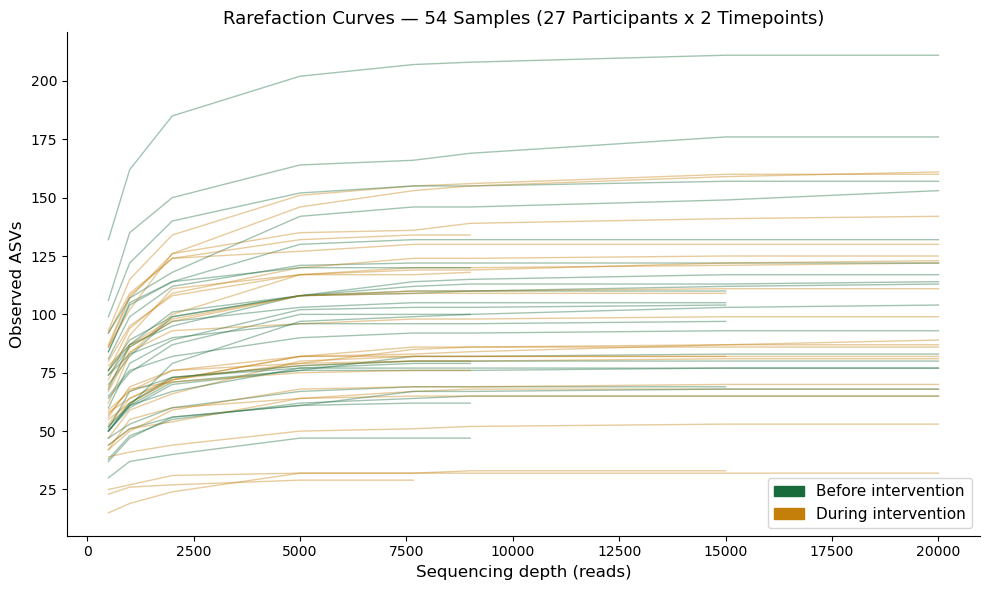

Rarefaction curve saved
Minimum sequencing depth: 7662 reads
Maximum sequencing depth: 79304 reads


In [18]:
from skbio.diversity import alpha_diversity
import matplotlib.patches as mpatches

# Transpose so rows = samples, columns = ASVs
asv_matrix = asv_table.T.fillna(0).astype(int)

# Subsampling depths
depths = [500, 1000, 2000, 5000, 9000, 15000, 20000, 
          int(asv_matrix.sum(axis=1).min())]
depths = sorted(set(depths))

rarefaction_results = []
for depth in depths:
    for sample in asv_matrix.index:
        counts = asv_matrix.loc[sample].values
        if counts.sum() >= depth:
            # Subsample
            np.random.seed(42)
            indices = np.repeat(np.arange(len(counts)), counts)
            subsampled = np.random.choice(indices, size=depth, replace=False)
            observed = len(np.unique(subsampled))
            rarefaction_results.append({'sample': sample, 'depth': depth, 'observed_asvs': observed})

raref_df = pd.DataFrame(rarefaction_results)

fig, ax = plt.subplots(figsize=(10, 6))
for sample in asv_matrix.index:
    sample_data = raref_df[raref_df['sample'] == sample]
    timepoint = 'before' if 'before' in sample else 'during'
    color = GREEN if timepoint == 'before' else GOLD
    ax.plot(sample_data['depth'], sample_data['observed_asvs'], 
            color=color, alpha=0.4, linewidth=1)

before_patch = mpatches.Patch(color=GREEN, label='Before intervention')
during_patch = mpatches.Patch(color=GOLD, label='During intervention')
ax.legend(handles=[before_patch, during_patch], fontsize=11)
ax.set_xlabel('Sequencing depth (reads)', fontsize=12)
ax.set_ylabel('Observed ASVs', fontsize=12)
ax.set_title('Rarefaction Curves — 54 Samples (27 Participants x 2 Timepoints)', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/rarefaction_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rarefaction curve saved")
print(f"Minimum sequencing depth: {asv_matrix.sum(axis=1).min():.0f} reads")
print(f"Maximum sequencing depth: {asv_matrix.sum(axis=1).max():.0f} reads")

### Interpretation

All 54 curves plateau well before 20,000 reads, confirming that sequencing depth
was sufficient to capture community diversity across all samples. Minimum depth:
7,662 reads. Maximum depth: 79,304 reads. Most curves flatten by 5,000-7,500 reads.

Two samples show curves still rising slightly at maximum depth — a minor limitation
noted for completeness. Overall, sequencing depth is adequate for valid alpha and
beta diversity comparisons across all 54 samples.

### 8. Alpha Diversity — Shannon Entropy and Chao1 Richness

Shannon entropy captures both richness and evenness of the microbial community.
Chao1 estimates true species richness by accounting for undetected rare species
using the frequency of singletons and doubletons. Both metrics are calculated
at full sequencing depth without rarefaction — consistent with current best
practice for 16S amplicon data.

Paired Wilcoxon signed-rank test compares before vs during intervention
within each participant, accounting for the paired study design.

In [20]:
from skbio.diversity import alpha_diversity

asv_matrix = asv_table.T.fillna(0).astype(int)

shannon_values = alpha_diversity('shannon', asv_matrix.values, ids=asv_matrix.index)
chao1_values = alpha_diversity('chao1', asv_matrix.values, ids=asv_matrix.index)

print(f"Shannon range: {shannon_values.min():.2f} to {shannon_values.max():.2f}")
print(f"Chao1 range: {chao1_values.min():.0f} to {chao1_values.max():.0f}")

Shannon range: 0.84 to 4.53
Chao1 range: 29 to 211


In [21]:
# build the alpha diversity DataFrame.
alpha_df = pd.DataFrame({
    'shannon': shannon_values,
    'chao1': chao1_values,
    'sample': asv_matrix.index
})
alpha_df['participant'] = alpha_df['sample'].str.extract(r'(U\d+)')
alpha_df['timepoint'] = alpha_df['sample'].apply(lambda x: 'Before' if 'before' in x else 'During')

alpha_df.head(6)

,shannon,chao1,sample,participant,timepoint
U307-before,4.193015,179.0,U307-before,U307,Before
U307-during,3.975221,160.0,U307-during,U307,During
U310-before,3.355466,110.0,U310-before,U310,Before
U310-during,3.751651,118.0,U310-during,U310,During
U311-before,3.485833,105.0,U311-before,U311,Before
U311-during,3.754399,142.0,U311-during,U311,During


In [22]:
#Paired Wilcoxon tests.
from scipy.stats import wilcoxon

before_shannon = alpha_df[alpha_df['timepoint']=='Before'].set_index('participant')['shannon']
during_shannon = alpha_df[alpha_df['timepoint']=='During'].set_index('participant')['shannon']
before_chao1 = alpha_df[alpha_df['timepoint']=='Before'].set_index('participant')['chao1']
during_chao1 = alpha_df[alpha_df['timepoint']=='During'].set_index('participant')['chao1']

_, p_shannon = wilcoxon(before_shannon, during_shannon)
_, p_chao1 = wilcoxon(before_chao1, during_chao1)

print(f"Shannon Wilcoxon p = {p_shannon:.4f}")
print(f"Chao1 Wilcoxon p = {p_chao1:.4f}")

Shannon Wilcoxon p = 0.0229
Chao1 Wilcoxon p = 0.0625


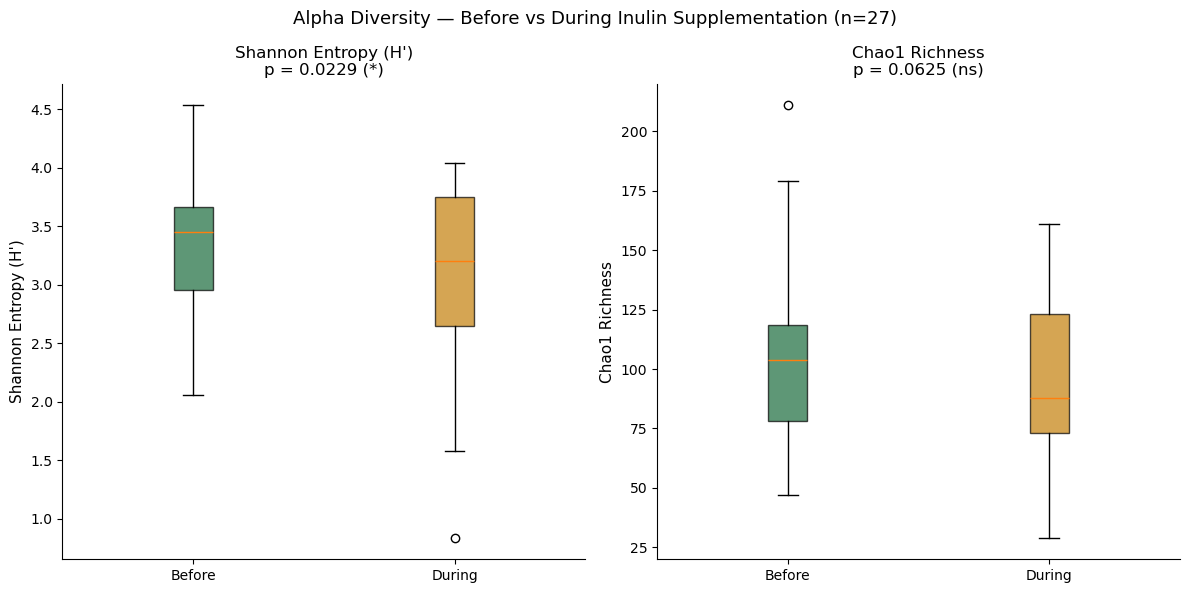

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, metric, p_val, label in zip(
    axes,
    ['shannon', 'chao1'],
    [p_shannon, p_chao1],
    ["Shannon Entropy (H')", 'Chao1 Richness']):

    data_before = alpha_df[alpha_df['timepoint']=='Before'][metric]
    data_during = alpha_df[alpha_df['timepoint']=='During'][metric]

    bp = ax.boxplot([data_before, data_during],
                    patch_artist=True,
                    labels=['Before', 'During'])
    bp['boxes'][0].set_facecolor(GREEN)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(GOLD)
    bp['boxes'][1].set_alpha(0.7)

    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.set_title(f'{label}\np = {p_val:.4f} ({sig})', fontsize=12)
    ax.set_ylabel(label, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Alpha Diversity — Before vs During Inulin Supplementation (n=27)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/qiime2/exported/alpha_diversity_shannon_chao1.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

Shannon entropy decreased significantly during inulin supplementation
(Wilcoxon p = 0.0229, *). The median Shannon value dropped from 3.47 before
to 3.18 during intervention, with increased spread in the during group —
reflecting heterogeneous responses across participants.

Chao1 richness did not change significantly (p = 0.0625, ns). The estimated
total number of species present was similar before and during supplementation.

Together these results indicate that inulin supplementation altered community
evenness rather than total species richness — consistent with selective
enrichment of specific fermenters (Bifidobacterium, Anaerostipes) within an
otherwise stable community structure. The one outlier in Chao1 before
intervention (>200 estimated species) represents a participant with unusually
high baseline diversity.